# 📈 11-00 · 时间序列基础与平稳性

> 目标：时间序列分析的**第一性原理**。手写 **ACF/PACF、差分、ADF 检验、Ljung-Box**，
> 在合成序列（趋势+季节+噪声）上亲手完成「识别非平稳 → 差分平稳化 → 白噪声诊断」全流程。

> 🧩 **生活化类比**：平稳性 = "规律稳定可外推"。心电图是平稳的（波峰波谷规律重复），
> 股价长期是"随机游走"（今天和昨天的差纯随机）——前者能预测，后者难。分析时间序列的第一步永远是：**它平稳吗？**


## 1. 时间序列的构成

$$y_t = T_t + S_t + C_t + \\epsilon_t \\quad(\\text{加法}) \\qquad
y_t = T_t \\cdot S_t \\cdot C_t \\cdot \\epsilon_t \\quad(\\text{乘法})$$

- $T$ 趋势（长期方向）、$S$ 季节（固定周期）、$C$ 周期（非固定）、$\\epsilon$ 噪声
- 分析顺序：**先分解/差分把非平稳成分去掉，再对平稳残差建模**


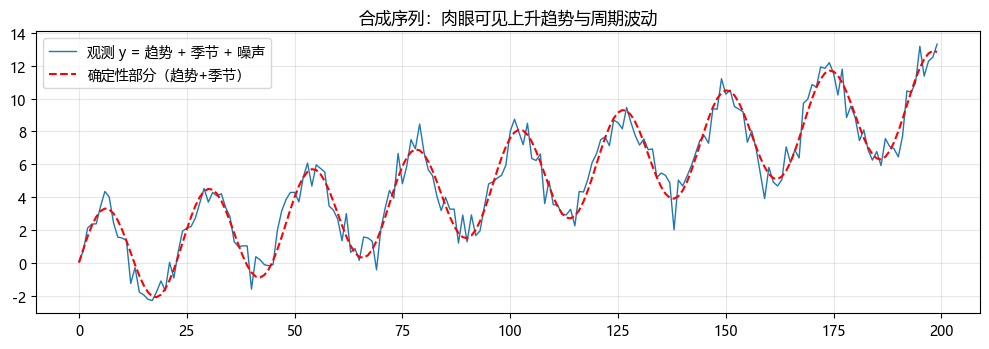

读图：均值随 t 上升（非平稳）；波动有固定周期（季节成分）


In [1]:
# ---------- 实验 1：合成序列（趋势 + 季节 + 噪声）可视化 ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

n = 200
t = np.arange(n)
trend = 0.05 * t
season = 3 * np.sin(2 * np.pi * t / 24)          # 周期 24
noise = rng.normal(0, 0.8, n)
y = trend + season + noise

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, y, lw=1, label='观测 y = 趋势 + 季节 + 噪声')
ax.plot(t, trend + season, 'r--', lw=1.5, label='确定性部分（趋势+季节）')
ax.legend(); ax.set_title('合成序列：肉眼可见上升趋势与周期波动'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/ts00_series.png', dpi=110, bbox_inches='tight'); plt.show()
print('读图：均值随 t 上升（非平稳）；波动有固定周期（季节成分）')


## 2. 平稳性：两种定义

- **强平稳**：任意时间平移下联合分布不变（严格，难验证）
- **弱平稳（实用）**：① 均值恒定 $E[y_t]=\\mu$；② 方差恒定；③ 协方差只依赖滞后 $k$：$\\gamma(k)=\\text{Cov}(y_t, y_{t-k})$

**为什么必须平稳**：统计建模需要"规律不随时间变"；非平稳序列的均值/方差本身在漂移，拟合出来的是"历史平均"而非"动态规律"。

> 面试高频：**随机游走 $y_t = y_{t-1} + \\epsilon_t$ 是非平稳的**（方差随 t 增长）；
> 但它的**一阶差分是白噪声（平稳）**。


随机游走：窗口方差随样本量增长 -> [ 7.71  6.53 10.9  25.6 ] ...
一阶差分后窗口方差 -> [1.464 1.38  1.306 1.282] （稳定）


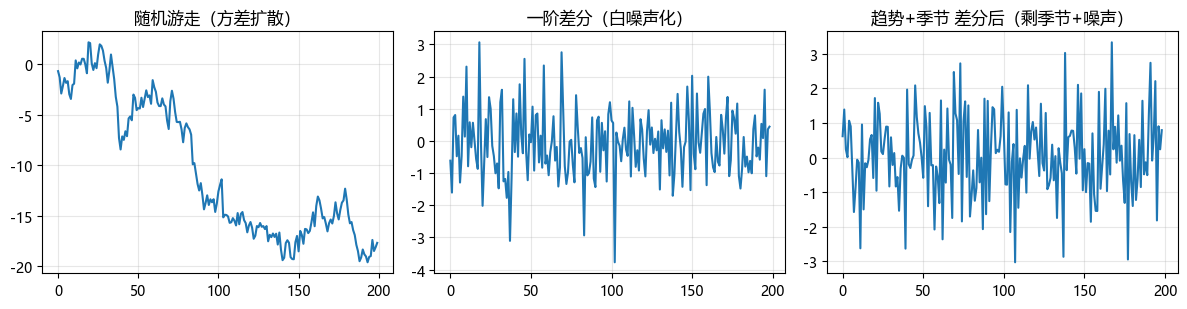

要点：差分是"去趋势/去随机游走"的第一把刀；季节差分（y_t - y_{t-24}）去周期


In [2]:
# ---------- 实验 2：手写差分 + 看方差漂移 ----------
def diff1(x):
    return x[1:] - x[:-1]

rw = np.cumsum(rng.normal(0, 1, n))              # 随机游走
var_windows = [np.var(rw[:k]) for k in range(50, n, 20)]
print('随机游走：窗口方差随样本量增长 ->', np.round(var_windows[:4], 2), '...')
d_rw = diff1(rw)
print('一阶差分后窗口方差 ->', np.round([np.var(d_rw[:k]) for k in range(50, n, 20)][:4], 3), '（稳定）')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(rw); axes[0].set_title('随机游走（方差扩散）')
axes[1].plot(d_rw); axes[1].set_title('一阶差分（白噪声化）')
axes[2].plot(diff1(y)); axes[2].set_title('趋势+季节 差分后（剩季节+噪声）')
for a in axes: a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/ts00_diff.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：差分是"去趋势/去随机游走"的第一把刀；季节差分（y_t - y_{t-24}）去周期')


## 3. ACF 与 PACF：自相关的指纹

- **ACF（自相关函数）**：$\\rho(k) = \\dfrac{\\gamma(k)}{\\gamma(0)}$ —— 与滞后 $k$ 自身的相关性
- **PACF（偏自相关）**：剔除中间滞后影响后，$y_t$ 与 $y_{t-k}$ 的纯相关
- 用途：识别模型阶数（AR 的 PACF 截尾、MA 的 ACF 截尾——01 篇详讲）

$$\\hat\\rho(k) = \\frac{\\sum_t (y_t - \\bar y)(y_{t-k} - \\bar y)}{\\sum_t (y_t - \\bar y)^2}$$


In [3]:
# ---------- 实验 3：手写 ACF / PACF ----------
def acf(x, max_lag=20):
    x = x - x.mean()
    v = np.dot(x, x)
    out = [1.0]                                        # ρ(0) ≡ 1，注意 x[:-0] 是空数组
    for k in range(1, max_lag + 1):
        out.append(np.dot(x[k:], x[:-k]) / v)
    return np.array(out)

def pacf(x, max_lag=10):
    # 逐阶回归：x_t ~ x_{t-1}..x_{t-k}，取 x_{t-k} 的系数（首列）为偏自相关
    out = [1.0]
    for k in range(1, max_lag + 1):
        X = np.stack([x[k - j:-j] for j in range(k, 0, -1)], axis=1)   # (n-k, k)，首列=最远滞后
        yy = x[k:]
        beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
        out.append(float(beta[0]))
    return np.array(out)

a = acf(d_rw, 20)
p = pacf(d_rw, 10)
print('白噪声化序列 ACF 前 5 项:', np.round(a[:5], 3), '（应≈0，±1.96/√n 为置信带）')
print('PACF 前 5 项:', np.round(p[:5], 3))
assert np.abs(a[1:]).max() < 0.25                # 白噪声 ACF 应全部接近 0
print('置信带 ≈ ±%.3f（置信水平 95%%）：越界的 ACF 提示存在自相关' % (1.96 / np.sqrt(len(d_rw))))


白噪声化序列 ACF 前 5 项: [ 1.    -0.046 -0.117 -0.038  0.011] （应≈0，±1.96/√n 为置信带）
PACF 前 5 项: [ 1.    -0.039 -0.112 -0.041  0.003]
置信带 ≈ ±0.139（置信水平 95%）：越界的 ACF 提示存在自相关


## 4. ADF 单位根检验（手写核心）

**单位根**：若 $y_t = \\rho y_{t-1} + \\epsilon_t$ 中 $\\rho = 1$ → 非平稳（随机游走）。

ADF 回归：$\\Delta y_t = \\alpha + \\beta t + \\gamma y_{t-1} + \\sum_{k} \\phi_k \\Delta y_{t-k} + e_t$

- 原假设 $H_0: \\gamma = 0$（有单位根，非平稳）
- 统计量 $t = \\hat\\gamma / \\text{se}(\\hat\\gamma)$，越负越拒绝
- 教学简化：OLS 拟合 $\\Delta y_t = \\alpha + \\gamma y_{t-1}$，临界值取 -2.86（5%，带常数）


In [4]:
# ---------- 实验 4：手写简化 ADF 检验 ----------
def adf_stat(x):
    dx = x[1:] - x[:-1]
    lag = x[:-1]
    A = np.stack([np.ones(len(dx)), lag], axis=1)
    beta, *_ = np.linalg.lstsq(A, dx, rcond=None)
    resid = dx - A @ beta
    se = np.sqrt((resid @ resid) / (len(dx) - 2) / np.sum((lag - lag.mean()) ** 2))
    return beta[1] / se                       # γ 的 t 统计量

s_rw = adf_stat(rw)
s_d = adf_stat(d_rw)
s_trend = adf_stat(y)
print('随机游走      ADF t=%.2f  （>-2.86 → 不拒绝单位根，非平稳）' % s_rw)
print('一阶差分后    ADF t=%.2f  （<-2.86 → 平稳）' % s_d)
print('趋势+季节序列 ADF t=%.2f  （非平稳）' % s_trend)
assert s_rw > -2.86 and s_d < -2.86 and s_trend > -2.86
print('结论：差分是让序列平稳的标准操作；检验"是否平稳"用 ADF（正式工具）')


随机游走      ADF t=-1.28  （>-2.86 → 不拒绝单位根，非平稳）
一阶差分后    ADF t=-14.66  （<-2.86 → 平稳）
趋势+季节序列 ADF t=-2.05  （非平稳）
结论：差分是让序列平稳的标准操作；检验"是否平稳"用 ADF（正式工具）


## 5. 白噪声与 Ljung-Box 检验

**白噪声**：$\\epsilon_t \\sim \\text{iid}(0, \\sigma^2)$，ACF 全为 0 —— 模型诊断的"理想终点"。

Ljung-Box：$Q = n(n+2)\\sum_{k=1}^{h} \\dfrac{\\hat\\rho_k^2}{n-k} \\sim \\chi^2_h$，Q 大 → 存在自相关（模型没学干净）。


In [5]:
# ---------- 实验 5：手写 Ljung-Box 检验 ----------
from math import erf, sqrt

def chi2_cdf_approx(x, df):   # 用 Wilson-Hilferty 近似 P(chi2_df <= x)
    z = ((x / df) ** (1 / 3) - (1 - 2 / (9 * df))) / sqrt(2 / (9 * df))
    return 0.5 * (1 + erf(z / sqrt(2)))

def ljung_box(x, h=10):
    a = acf(x, h)[1:]
    n = len(x)
    Q = n * (n + 2) * np.sum(a ** 2 / (n - np.arange(1, h + 1)))
    return Q, 1 - chi2_cdf_approx(Q, h)

wn = rng.normal(0, 1, 300)
Q_w, p_w = ljung_box(wn)
Q_ar, p_ar = ljung_box(y)                       # 未处理的序列当然显著相关
print('白噪声  Q=%.2f p=%.3f（p>0.05 → 无法拒绝"无自相关"）' % (Q_w, p_w))
print('原始序列 Q=%.2f p=%.3f（p<0.05 → 存在自相关）' % (Q_ar, p_ar))
assert p_w > 0.05 and p_ar < 0.05
print('要点：模型残差若通不过 Ljung-Box，说明信息没提取干净，需要加结构')


白噪声  Q=5.04 p=0.889（p>0.05 → 无法拒绝"无自相关"）
原始序列 Q=853.92 p=0.000（p<0.05 → 存在自相关）
要点：模型残差若通不过 Ljung-Box，说明信息没提取干净，需要加结构


## 6. 面试速答（30 秒背诵版）

- **平稳性三条件**：均值/方差恒定、协方差只依赖滞后
- **为什么需要平稳**：统计规律不随时间漂移，模型才可外推
- **随机游走非平稳**：方差随 t 增长；差分后变白噪声
- **ADF**：$\\Delta y_t = \\alpha + \\beta t + \\gamma y_{t-1}+\\dots$，检验 $\\gamma=0$，t 越负越拒绝
- **ACF/PACF**：自相关指纹，用于定阶（AR→PACF 截尾，MA→ACF 截尾）
- **白噪声/Ljung-Box**：残差理想状态；Q 大拒绝无自相关
- **处理流程**：看图 → 平稳化（差分/分解）→ 建模 → 残差诊断 → 预测


## 7. 自测清单

- [ ] 手写 ACF 公式并实现（与 1.96/√n 置信带对照）
- [ ] 手写一阶差分与季节差分（y_t − y_{t−24}）
- [ ] 手写简化 ADF（OLS + t 统计量）并解释拒绝/不拒绝
- [ ] 手写 Ljung-Box 并解释 p 值含义
- [ ] 说出随机游走为何非平稳、差分后为何平稳
- [ ] 口算：95% ACF 置信带 ≈ ±1.96/√n
- [ ] 画出「趋势+季节+噪声」分解图

> 💡 下一篇 `01-ARMA 与 ARIMA` 在平稳序列上建立第一个正经预测模型。
